# Winsorization - California Housing Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize


In [2]:
df = pd.read_csv('5_Winsorization_CaliforniaHousing.csv')
df['AveRooms'].describe()

count    200.000000
mean       7.517950
std       14.015673
min        1.890000
25%        4.370000
50%        5.445000
75%        6.760000
max      141.000000
Name: AveRooms, dtype: float64

In [ ]:
# capping top 5% and bottom 5%
df['AveRooms_wins'] = winsorize(df['AveRooms'], limits=[0.05, 0.05])
df[['AveRooms','AveRooms_wins']].describe()


c:\Users\Gokul\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,AveRooms,AveRooms_wins
count,200.000000,200.000000
mean,7.517950,5.587800
std,14.015673,1.471077
min,1.890000,3.130000
25%,4.370000,4.370000
50%,5.445000,5.445000
75%,6.760000,6.760000
max,141.000000,8.410000


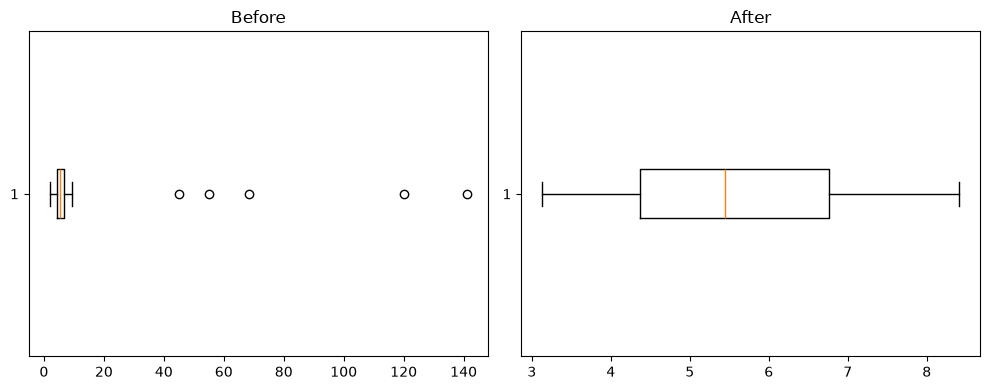

In [8]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].boxplot(df['AveRooms'], orientation='horizontal')
ax[0].set_title('Before')
ax[1].boxplot(df['AveRooms_wins'], orientation='horizontal')
ax[1].set_title('After')
plt.tight_layout()
plt.show()

In [3]:
from feature_engine.outliers import Winsorizer

wz = Winsorizer(
    capping_method='quantiles',
    tail='both',
    fold=0.05,
    variables=['AveRooms']
)

df_wins = wz.fit_transform(df)

df['AveRooms_wins_fe'] = df_wins['AveRooms']

df[['AveRooms', 'AveRooms_wins', 'AveRooms_wins_fe']].describe()

print(df.head())
print(df.columns)

NameError: name 'df' is not defined